we have an issue with getting images out of the dataset 'python versions scrpts' 

In [47]:
import os
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt
from PIL import Image

os.chdir(r"C:\Users\Asus\grocery-cv-project")

print("Current directory:", os.getcwd())

Current directory: C:\Users\Asus\grocery-cv-project


In [48]:
FREIBURG_DIR = Path("data/raw/freiburg_groceries/images")

EGYPT_DIR = Path(
    "data/raw/egyptain_food/Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip/train"
)

print("Freiburg exists:", FREIBURG_DIR.exists())
print("Egyptian exists:", EGYPT_DIR.exists())

Freiburg exists: True
Egyptian exists: True


In [49]:
def collect_images(folder):
    extensions = ["*.jpg", "*.jpeg", "*.png"]
    images = []

    for ext in extensions:
        images.extend(list(folder.rglob(ext)))

    return images


freiburg_images = collect_images(FREIBURG_DIR)
egypt_images = collect_images(EGYPT_DIR)

print("Freiburg images:", len(freiburg_images))
print("Egyptian images:", len(egypt_images))

random_freiburg = random.sample(freiburg_images, min(3, len(freiburg_images)))
random_egypt = random.sample(egypt_images, min(3, len(egypt_images)))

test_images = random_freiburg + random_egypt

random.shuffle(test_images)

for img in test_images:
    print(img)

Freiburg images: 4947
Egyptian images: 353
data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Max Tea Biscuits\20250330_214343_jpg.rf.df0c870d794ee23c0e2e937e9820288b.jpg
data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Shepsy Salt and Vinegar Chips\20250330_221048_jpg.rf.dd50e1f32f434ab64f94786b728ca952.jpg
data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Signal Cavity Fighter\20250517_142625_jpg.rf.c4218f44a8db1b74474068cd863a260e.jpg
data\raw\freiburg_groceries\images\CEREAL\CEREAL0038.png
data\raw\freiburg_groceries\images\CANDY\CANDY0170.png
data\raw\freiburg_groceries\images\HONEY\HONEY0130.png


In [50]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")

print("YOLOv8 loaded successfully")

YOLOv8 loaded successfully


In [51]:
def run_yolo_detection(image_path, conf=0.25):
    image_path = Path(image_path)

    results = yolo_model(str(image_path), conf=conf)

    result = results[0]

    img_bgr = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    boxes = result.boxes

    detections = []

    if len(boxes) == 0:
        return img_rgb, detections, "No detection"

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        confidence = float(box.conf[0])
        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]

        detections.append({
            "class_name": class_name,
            "confidence": confidence,
            "box": (x1, y1, x2, y2)
        })

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)

        label = f"object {confidence:.2f}"
        cv2.putText(
            img_rgb,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    return img_rgb, detections, "Detected"


image 1/1 C:\Users\Asus\grocery-cv-project\data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Max Tea Biscuits\20250330_214343_jpg.rf.df0c870d794ee23c0e2e937e9820288b.jpg: 640x640 (no detections), 51.1ms
Speed: 2.5ms preprocess, 51.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


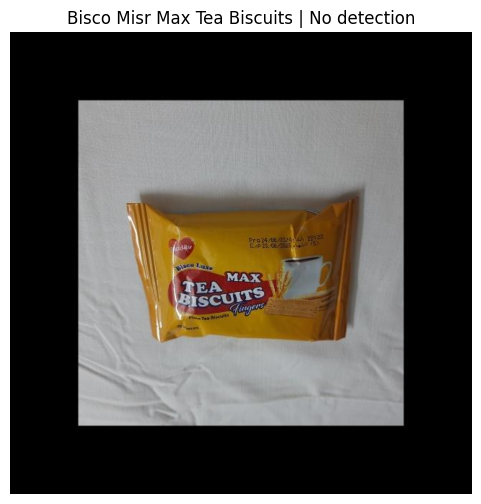

Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Max Tea Biscuits\20250330_214343_jpg.rf.df0c870d794ee23c0e2e937e9820288b.jpg
YOLO result: No object detected
----------------------------------------------------------------------

image 1/1 C:\Users\Asus\grocery-cv-project\data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Shepsy Salt and Vinegar Chips\20250330_221048_jpg.rf.dd50e1f32f434ab64f94786b728ca952.jpg: 640x640 1 person, 48.1ms
Speed: 4.4ms preprocess, 48.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


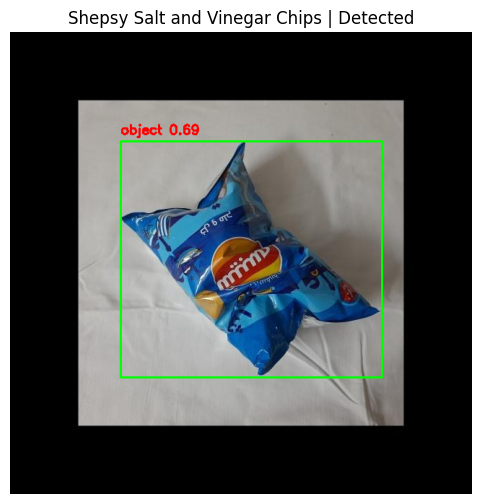

Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Shepsy Salt and Vinegar Chips\20250330_221048_jpg.rf.dd50e1f32f434ab64f94786b728ca952.jpg
Detected object region | COCO label: person | Confidence: 0.69
----------------------------------------------------------------------

image 1/1 C:\Users\Asus\grocery-cv-project\data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Signal Cavity Fighter\20250517_142625_jpg.rf.c4218f44a8db1b74474068cd863a260e.jpg: 640x640 1 cell phone, 51.4ms
Speed: 4.1ms preprocess, 51.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


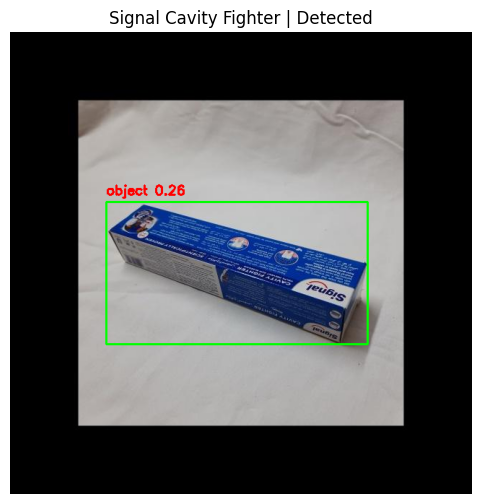

Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Signal Cavity Fighter\20250517_142625_jpg.rf.c4218f44a8db1b74474068cd863a260e.jpg
Detected object region | COCO label: cell phone | Confidence: 0.26
----------------------------------------------------------------------

image 1/1 C:\Users\Asus\grocery-cv-project\data\raw\freiburg_groceries\images\CEREAL\CEREAL0038.png: 640x640 1 bottle, 46.8ms
Speed: 3.3ms preprocess, 46.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


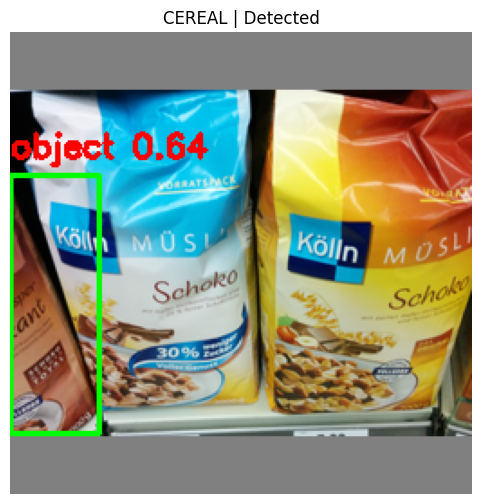

Image: data\raw\freiburg_groceries\images\CEREAL\CEREAL0038.png
Detected object region | COCO label: bottle | Confidence: 0.64
----------------------------------------------------------------------

image 1/1 C:\Users\Asus\grocery-cv-project\data\raw\freiburg_groceries\images\CANDY\CANDY0170.png: 640x640 2 donuts, 45.4ms
Speed: 4.6ms preprocess, 45.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


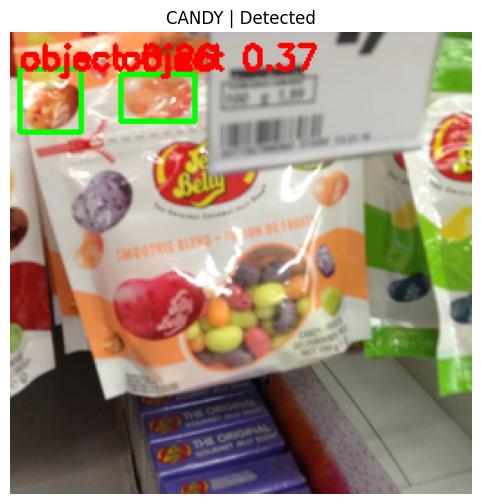

Image: data\raw\freiburg_groceries\images\CANDY\CANDY0170.png
Detected object region | COCO label: donut | Confidence: 0.37
Detected object region | COCO label: donut | Confidence: 0.26
----------------------------------------------------------------------

image 1/1 C:\Users\Asus\grocery-cv-project\data\raw\freiburg_groceries\images\HONEY\HONEY0130.png: 640x640 2 cups, 44.0ms
Speed: 3.2ms preprocess, 44.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


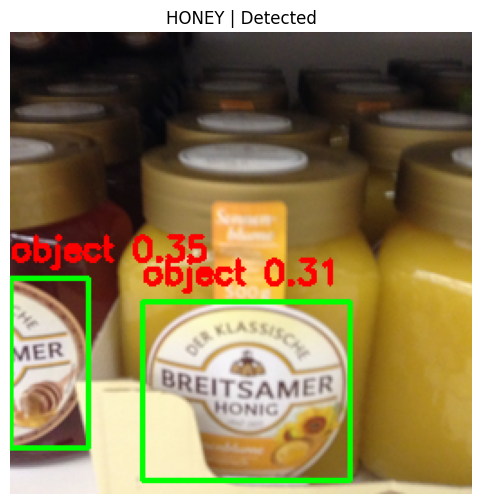

Image: data\raw\freiburg_groceries\images\HONEY\HONEY0130.png
Detected object region | COCO label: cup | Confidence: 0.35
Detected object region | COCO label: cup | Confidence: 0.31
----------------------------------------------------------------------


In [52]:
for image_path in test_images:
    detected_img, detections, status = run_yolo_detection(image_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(detected_img)
    plt.axis("off")
    plt.title(f"{image_path.parent.name} | {status}")
    plt.show()

    print("Image:", image_path)

    if len(detections) == 0:
        print("YOLO result: No object detected")
    else:
        for d in detections:
           print(f"Detected object region | COCO label: {d['class_name']} | Confidence: {d['confidence']:.2f}")

    print("-" * 70)

In [53]:
CROP_DIR = Path("results/yolo_crops")
CROP_DIR.mkdir(parents=True, exist_ok=True)

def save_yolo_crops(image_path, conf=0.25):
    image_path = Path(image_path)

    results = yolo_model(str(image_path), conf=conf)
    result = results[0]

    img = Image.open(image_path).convert("RGB")
    boxes = result.boxes

    saved_crops = []

    if len(boxes) == 0:
        return saved_crops

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

        crop = img.crop((x1, y1, x2, y2))

        crop_path = CROP_DIR / f"{image_path.stem}_crop_{i}.jpg"
        crop.save(crop_path)

        saved_crops.append(crop_path)

    return saved_crops

In [54]:
for image_path in test_images:
    crops = save_yolo_crops(image_path)

    print("Image:", image_path)

    if len(crops) == 0:
        print("No crops saved")
    else:
        for crop in crops:
            print("Saved crop:", crop)

    print("-" * 70)


image 1/1 C:\Users\Asus\grocery-cv-project\data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Max Tea Biscuits\20250330_214343_jpg.rf.df0c870d794ee23c0e2e937e9820288b.jpg: 640x640 (no detections), 53.1ms
Speed: 3.6ms preprocess, 53.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Image: data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Bisco Misr Max Tea Biscuits\20250330_214343_jpg.rf.df0c870d794ee23c0e2e937e9820288b.jpg
No crops saved
----------------------------------------------------------------------

image 1/1 C:\Users\Asus\grocery-cv-project\data\raw\egyptain_food\Egyptian Products 25cls.v1-raw-8cls-2025-05-20-2-28pm.clip\train\Shepsy Salt and Vinegar Chips\20250330_221048_jpg.rf.dd50e1f32f434ab64f94786b728ca952.jpg: 640x640 1 person, 82.3ms
Speed: 2.9ms preprocess, 82.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Image: data\raw\egyptain_food\Egypti